In [1]:
# Yukawa potential bound-state solver
# Radial Schrodinger equation with Numerov matching

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from jwanglibs import rootfinder as rtf

In [ ]:
# ===================
# Global parameters
# ===================
m = 1.0
hbar = 1.0
V0 = 0.1
a = 0.1
lamda = 0.1          # screening parameter
xL = 1.0**(-5)       # start slightly away from r=0
xR = 40.0            # outer boundary
N = 4000             # number of intervals
h = (xR-xL)/N
Lmax = 4             # solve for L = 0,1,2,3
M = N // 2           # matching index
tol = 1.0**(-8)
# Global variables used by f(r)
E = -0.1
L = 0

In [34]:
# ========================
# Define Yukawa Potential
# ========================
def V(r):
    """
    Piecewise potential:
      inside r < a: constant well = -V0
      outside r >= a: Yukawa tail = -V0 exp(-lamda r)/r

    If you want a pure Yukawa potential everywhere, replace this with:
        return -V0*np.exp(-lamda*r)/r
    """
    if r < a:
        return -V0
    return -V0*np.exp(-lamda*r)/r

In [35]:
# ===========================
# Define Effective Potential
# ===========================
def V_eff(r):
    """
    Effective potential for the reduced radial equation u(r):
        u''(r) + f(r) u(r) = 0
    where
        f(r) = 2m(E - V_eff)/hbar^2
    """
    centrifugal = hbar**2*L*(L+1)/(2.0*m*r**2)
    return centrifugal + V(r)

In [36]:
# ========================
# Define Numerov Schr Eqn
# ========================
def f(r):
    return 2.0*m*(E-V_eff(r))/hbar**2

In [37]:
# ====================
# Define Numerov func
# ====================
def numerov(f, u0, u1, n, x, h):
    """
    Numerov integrator for:
        u'' + f(x) u = 0

    Inputs:
      u0, u1 = first two values
      n      = number of additional steps
      x      = starting x corresponding to u0
      h      = step size

    Returns:
      u      = list [u0, u1, ..., u_{n+1}]
      nodes  = number of sign changes
    """
    u = [u0, u1]
    nodes = 0
    c = h**2/12.0
    f0 = f(x)
    f1 = f(x+h)
    for i in range(n):
        x2 = x + 2.0*h
        f2 = f(x2)
        unew = (2.0*(1.0-5.0*c*f1)*u[i+1]-(1.0+c*f0)*u[i])/(1.0+c*f2)
        u.append(unew)
        if u[-1] * u[-2] < 0.0:
            nodes += 1
        x += h
        f0, f1 = f1, f2

    return np.array(u), nodes

In [38]:
# =====================================
# Initial conditions near the origin
# =====================================
def origin_ic(L, r0, h):
    """
    Near r=0, the regular reduced radial solution behaves like:
        u(r) ~ r^(L+1)

    So use:
        u(xL)       = xL^(L+1)
        u(xL + h)   = (xL + h)^(L+1)
    """
    return r0**(L+1), (r0+h)**(L+1)

In [39]:
# ==========================================
# Initial conditions from the outer boundary
# ==========================================
def outer_ic(kappa, xR, h):
    """
    For a bound state at large r, u(r) ~ exp(-kappa r),
    where kappa = sqrt(-2mE)/hbar for E < 0.
    """
    uR = np.exp(-kappa*xR)
    uRm = np.exp(-kappa*(xR-h))
    return uR, uRm

In [40]:
# ==================
# Define shoot func
# ==================
def shoot(En):
    """
    Match logarithmic derivatives of inward and outward Numerov solutions
    at the matching point.
    """
    global E
    E = En
    if E >= 0.0:
        return np.nan
    
    kappa = np.sqrt(-2.0*m*E)/hbar  # approximate asymptotic decay constant
    u0, u1 = origin_ic(L, xL, h)  # outward integration from the origin
    wfup, nup = numerov(f, u0, u1, M-1, xL, h)
    uR, uRm = outer_ic(kappa, xR, h)  # inward integration from xR
    wfdn, ndn = numerov(f, uR, uRm, N-M-1, xR, -h)  # numerov expects first two points in the integration direction: xR, xR-h, then continue with step -h
    wfdn = wfdn[::-1]  # reverse inward solution so its indexing matches increasing r
    xm = xL+M*h  # matching radius    
    if abs(wfdn[0]) < 1e-14:  # scale inward solution to match amplitude
        return np.nan
    scale = wfup[-1] / wfdn[0]
    wfdn *= scale

    # logarithmic derivative mismatch
    dup = (wfup[-1] - wfup[-3]) / (2.0 * h)  # outward side derivative
    ddn = (wfdn[2] - wfdn[0]) / (2.0 * h)  # inward side derivative
    if abs(wfup[-2]) < 1e-14 or abs(wfdn[1]) < 1e-14:  # return mismatch in logarithmic derivative
        return np.nan

    return dup / wfup[-2] - ddn / wfdn[1]

In [41]:
# ==========================
# Build full matched wavefn
# ==========================
def build_wavefunction(Eval, Lval):
    global E, L
    E, L = Eval, Lval

    kappa = np.sqrt(-2.0 * m * E) / hbar

    u0, u1 = origin_ic(L, xL, h)
    wfup, _ = numerov(f, u0, u1, M - 1, xL, h)

    uR, uRm = outer_ic(kappa, xR, h)
    wfdn, _ = numerov(f, uR, uRm, N - M - 1, xR, -h)
    wfdn = wfdn[::-1]

    # scale inward solution to match outward solution
    scale = wfup[-1] / wfdn[0]
    wfdn *= scale

    # stitch together
    u = np.concatenate((wfup[:-1], wfdn))
    r = np.linspace(xL, xR, len(u))

    # normalize u(r) so integral |u|^2 dr = 1
    norm = np.sqrt(np.trapz(u**2, r))
    if norm > 0:
        u /= norm

    return r, u

In [42]:
# ===========================
# Scan energies for states
# ===========================
def find_states_for_L(Lval, Emin, Emax, dE):
    global L
    L = Lval
    states = []
    Egrid = np.arange(Emin, Emax, dE)
    last_root = None

    for i in range(len(Egrid) - 1):
        E1 = Egrid[i]
        E2 = Egrid[i + 1]
        s1 = shoot(E1)
        s2 = shoot(E2)
        if np.isnan(s1) or np.isnan(s2):
            continue
        if s1 * s2 > 0.0:
            continue
        try:
            root = rtf.bisect(shoot, E1, E2, tol)
        except Exception:
            continue
        if last_root is not None and abs(root - last_root) < 1e-5:  # prevent duplicates
            continue
        r, u = build_wavefunction(root, Lval)  # count nodes
        nodes = np.sum(u[1:] * u[:-1] < 0.0)
        states.append((root, nodes))
        last_root = root

    return states

In [43]:
# ===================
# Solve all channels
# ===================
EL = []

# choose a scan range for bound states
Emin = -1.5 * V0
Emax = -1e-4
dE = 0.002

for L in range(Lmax):
    states = find_states_for_L(L, Emin, Emax, dE)
    EL.append(states)
    for i, (Eval, nodes) in enumerate(states):
        n = nodes + L + 1  # for central potentials, principal-like label is often n = nodes + L + 1
        print(f"L = {L}, state {i+1}, nodes = {nodes}, n = {n}, E = {Eval:.8f}")

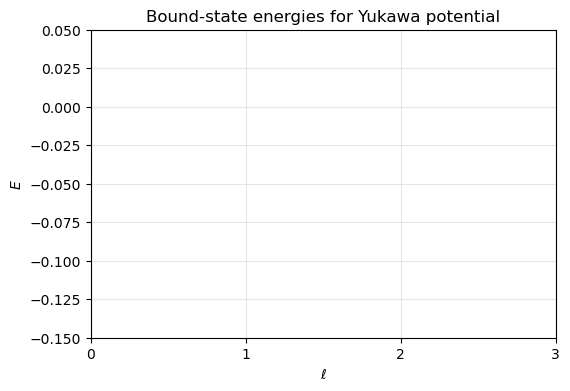

/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_26240/3790242800.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


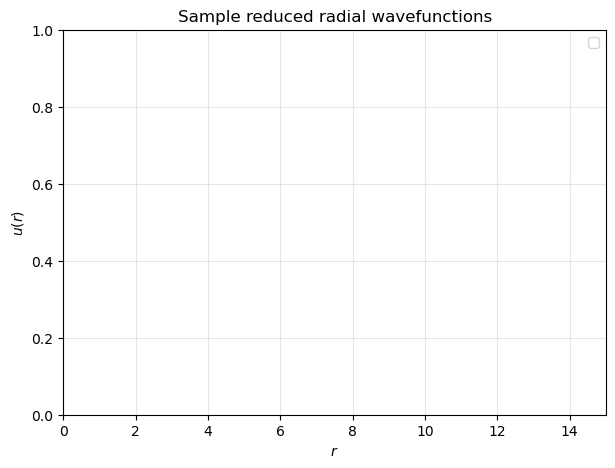

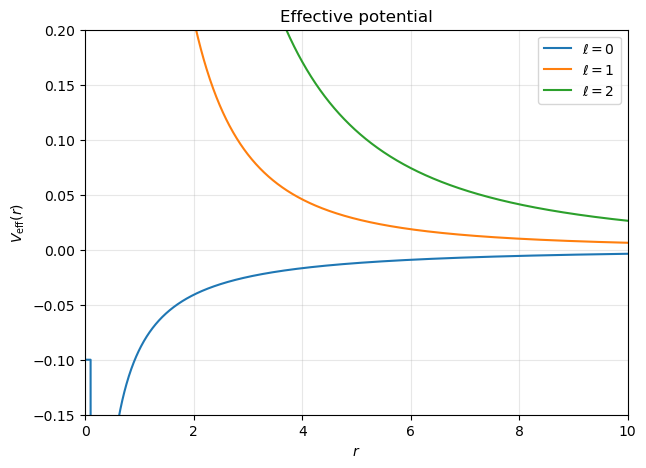

In [47]:
# =========
# Plotting
# =========
# Energy level plot
plt.figure(figsize=(6, 4))
for L in range(Lmax):
    for Eval, nodes in EL[L]:
        plt.plot([L - 0.25, L + 0.25], [Eval, Eval], 'k-')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$E$')
plt.title('Bound-state energies for Yukawa potential')
plt.xticks(range(Lmax))
plt.ylim(Emin, 0.05)
plt.grid(alpha=0.3)
plt.show()

# Plot a few wavefunctions
plt.figure(figsize=(7, 5))
for L in range(min(Lmax, 3)):
    if len(EL[L]) == 0:
        continue
    Eval = EL[L][0][0]   # lowest state for each L
    r, u = build_wavefunction(Eval, L)
    plt.plot(r, u, label=fr'$\ell={L}$, $E={Eval:.3f}$')

plt.xlabel(r'$r$')
plt.ylabel(r'$u(r)$')
plt.title('Sample reduced radial wavefunctions')
plt.xlim(0, 15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Plot the effective potential for reference
rplot = np.linspace(xL, 15, 2000)

plt.figure(figsize=(7, 5))
for L in range(min(Lmax, 3)):
    Veff_plot = hbar**2 * L * (L + 1) / (2.0 * m * rplot**2) + np.array([V(r) for r in rplot])
    plt.plot(rplot, Veff_plot, label=fr'$\ell={L}$')

plt.xlabel(r'$r$')
plt.ylabel(r'$V_{\mathrm{eff}}(r)$')
plt.title('Effective potential')
plt.ylim(-1.5*V0, 2.0*V0)
plt.xlim(0, 10)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Bound-state energies:
n=1, l=0, E = -1.932561


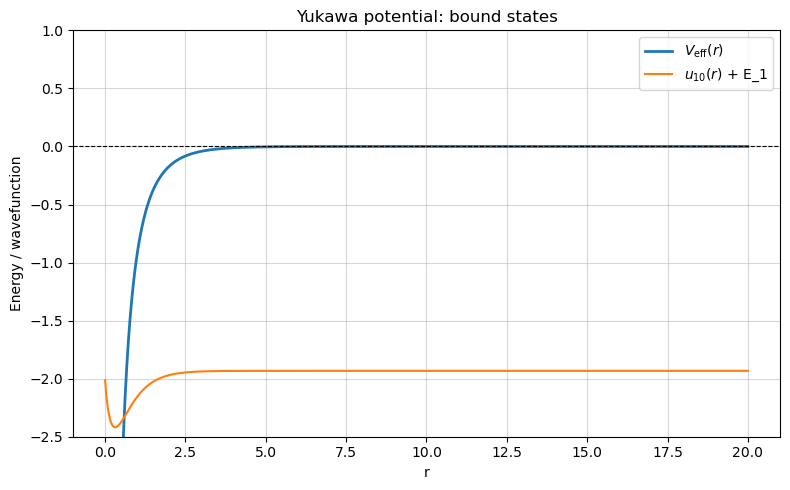

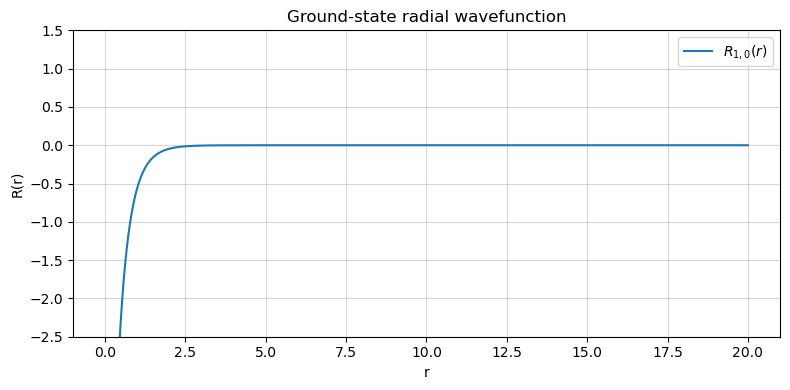

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.constants import e, hbar, m_p

# Yukawa radial solver in natural units: hbar = m = 1
hbar, m = 1.0, 1.0
g, mu = 2.5, 1.0          # potential strength and screening
l = 0                     # angular momentum quantum number
rmin, rmax, N = 1e-3, 20.0, 2000

# Radial grid
r = np.linspace(rmin, rmax, N)
dr = r[1] - r[0]

# Yukawa + centrifugal effective potential
V = -g * np.exp(-mu * r) / r
Veff = V + hbar**2 * l * (l + 1) / (2 * m * r**2)

# Finite-difference Hamiltonian for u(r)
kin = hbar**2 / (2 * m * dr**2)
diag = 2 * kin + Veff
offdiag = -kin * np.ones(N - 1)

# Solve H u = E u
E, U = eigh_tridiagonal(diag, offdiag)

# Keep only bound states (E < 0)
bound = np.where(E < 0)[0]
if len(bound) == 0:
    print("No bound states found for these parameters.")
    raise SystemExit

print("Bound-state energies:")
for n, i in enumerate(bound[:5], start=1):
    print(f"n={n}, l={l}, E = {E[i]:.6f}")

# Plot potential and first few bound states
plt.figure(figsize=(8, 5))
plt.plot(r, Veff, label=r"$V_{\mathrm{eff}}(r)$", linewidth=2)

for n, i in enumerate(bound[:3], start=1):
    u = U[:, i]
    u /= np.sqrt(np.trapezoid(u**2, r))      # normalize u(r)
    R = u / r                            # radial wf R(r)
    plt.plot(r, 0.4 * u + E[i], label=fr"$u_{{{n}{l}}}(r)$ + E_{n}")

plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylim(-2.5, 1.0)
plt.xlabel("r")
plt.ylabel("Energy / wavefunction")
plt.title("Yukawa potential: bound states")
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: inspect one radial wavefunction explicitly
i = bound[0]
u = U[:, i]
u /= np.sqrt(np.trapezoid(u**2, r))
R = u / r

plt.figure(figsize=(8, 4))
plt.plot(r, R, label=fr"$R_{{1,{l}}}(r)$")
plt.ylim(-2.5, 1.5)
plt.xlabel("r")
plt.ylabel("R(r)")
plt.title("Ground-state radial wavefunction")
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()